In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("./data/winequality-white.csv", sep=";")
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


============================== fixed acidity ==============================


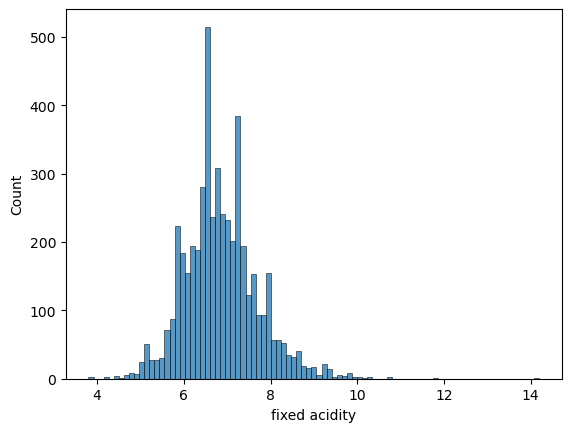

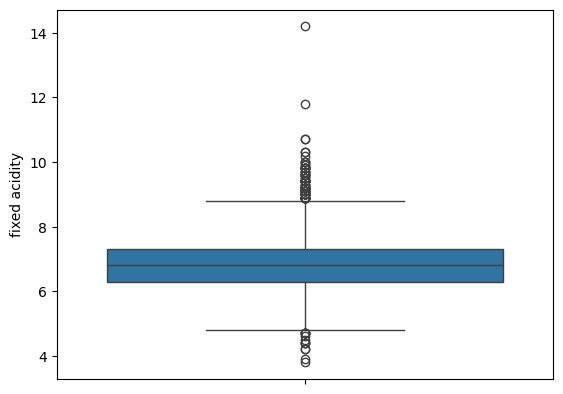

============================== volatile acidity ==============================


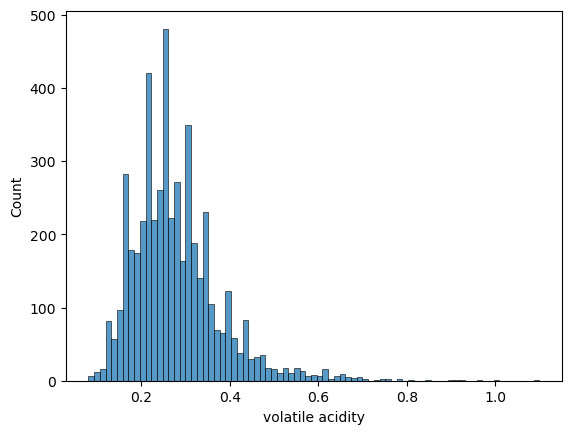

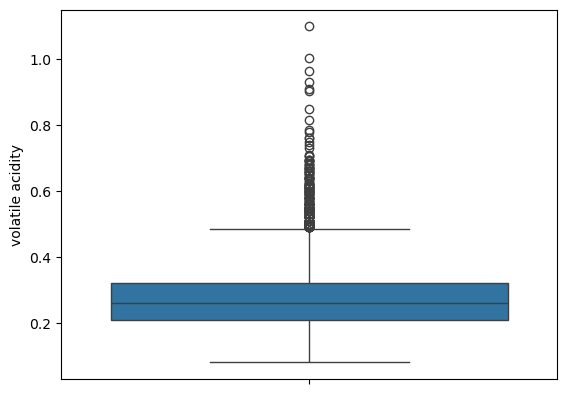

============================== citric acid ==============================


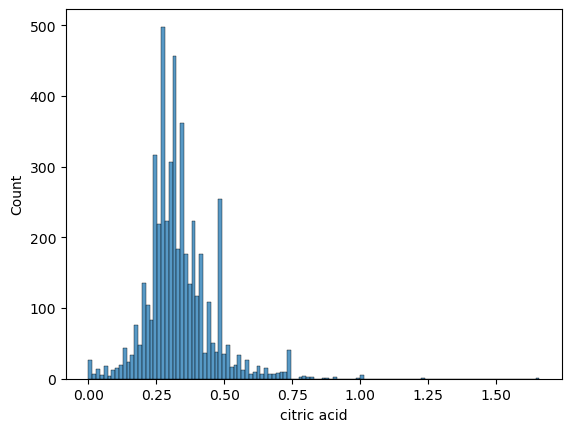

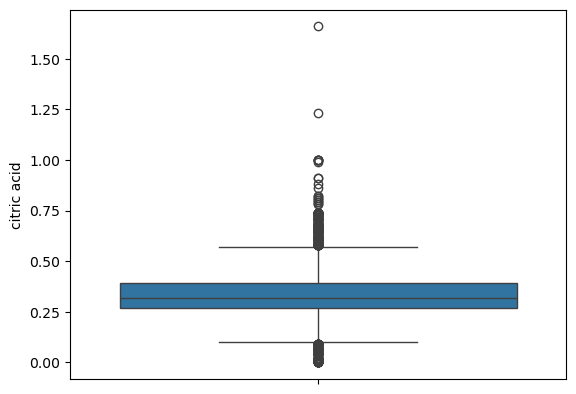

============================== residual sugar ==============================


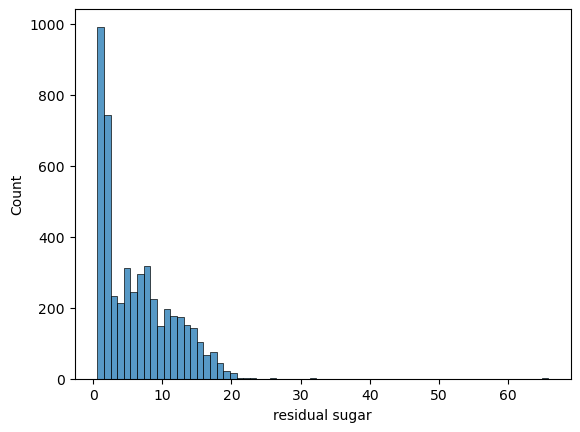

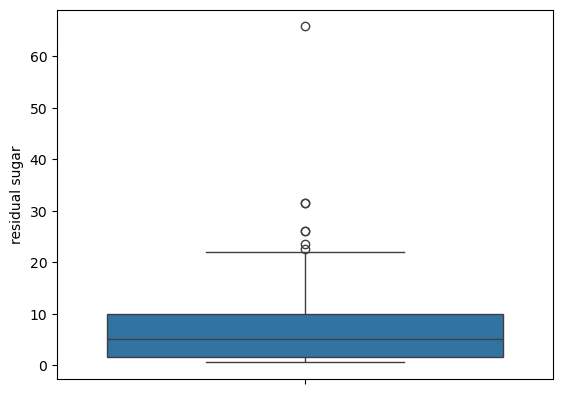

============================== chlorides ==============================


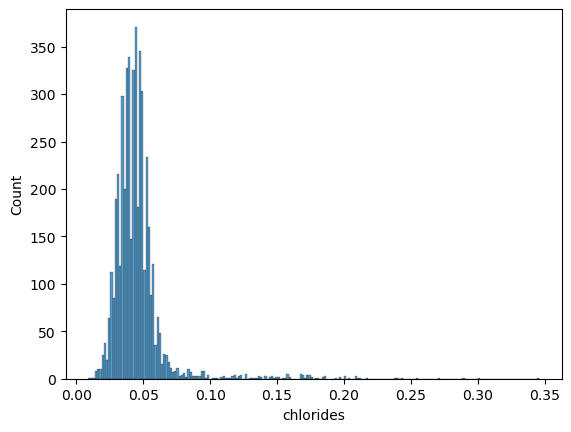

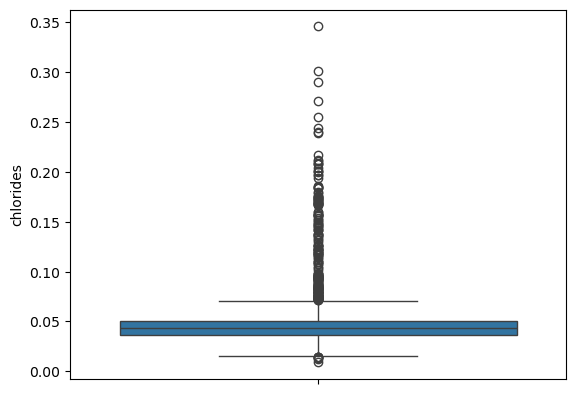

============================== free sulfur dioxide ==============================


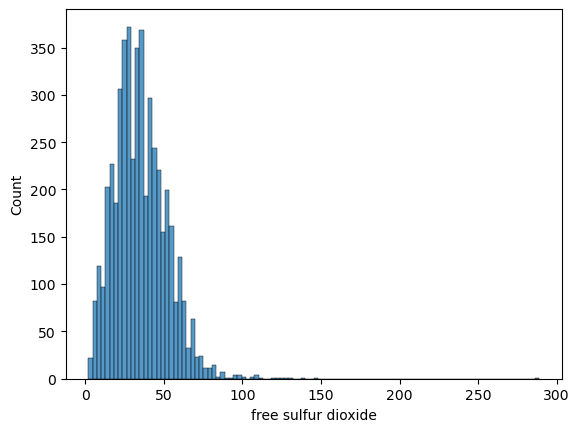

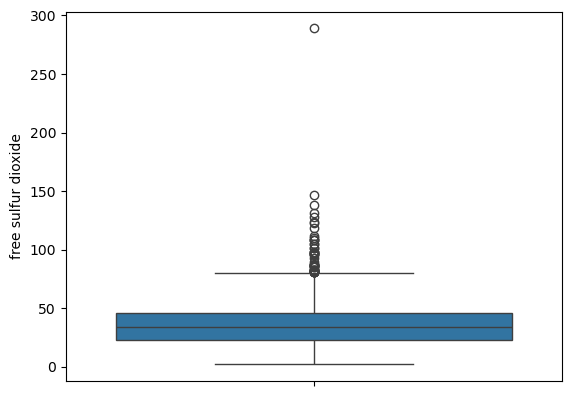

============================== total sulfur dioxide ==============================


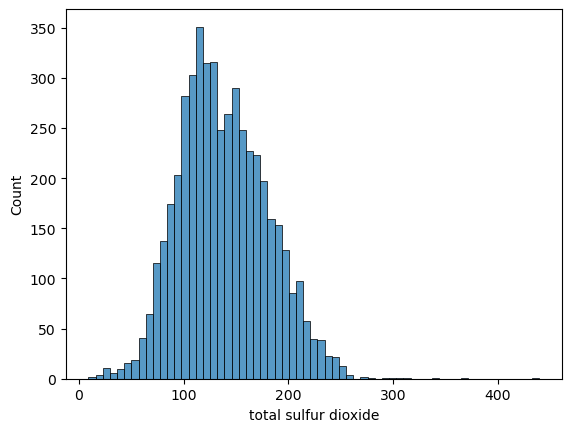

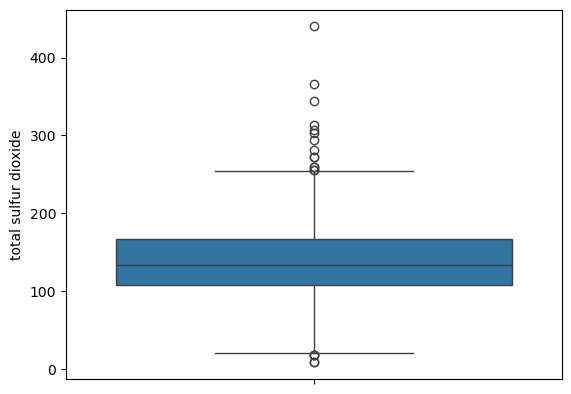

============================== density ==============================


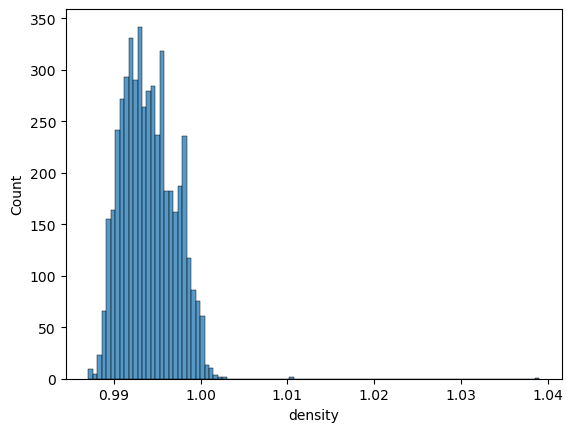

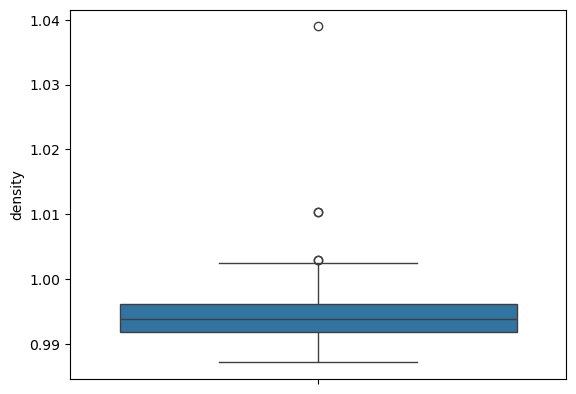

============================== pH ==============================


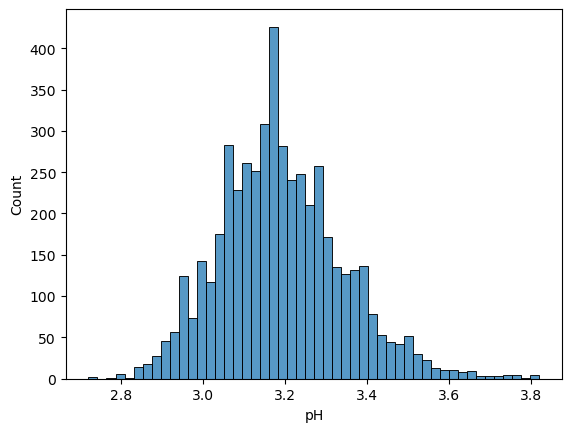

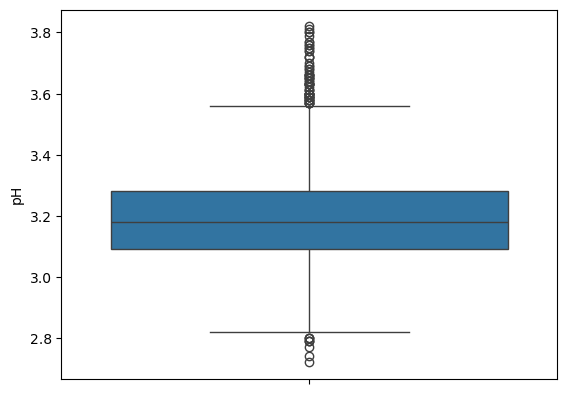

============================== sulphates ==============================


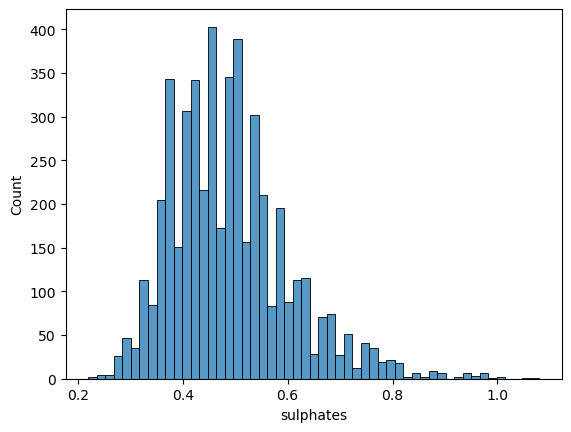

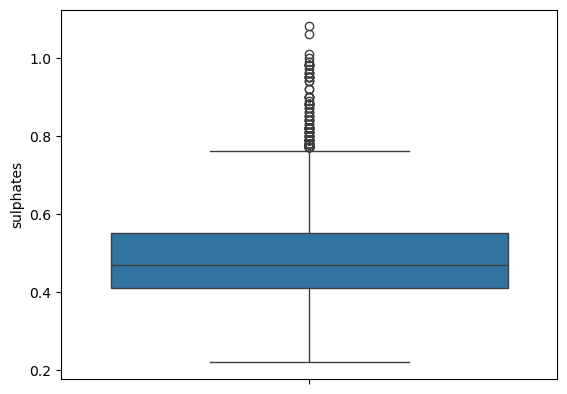

============================== alcohol ==============================


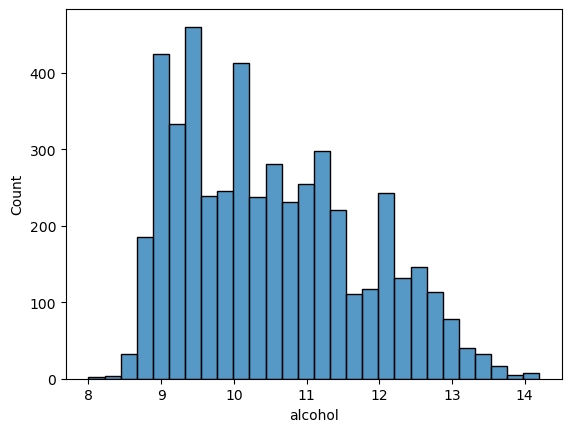

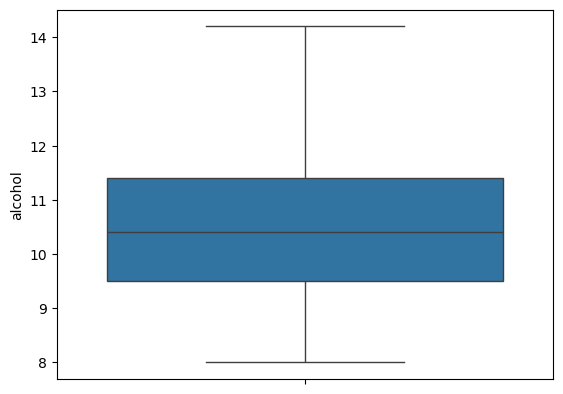

============================== quality ==============================


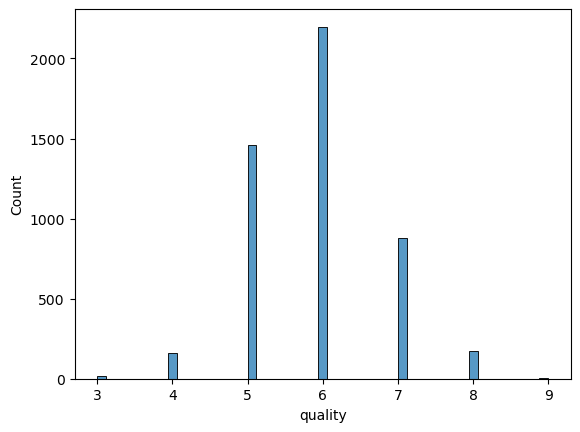

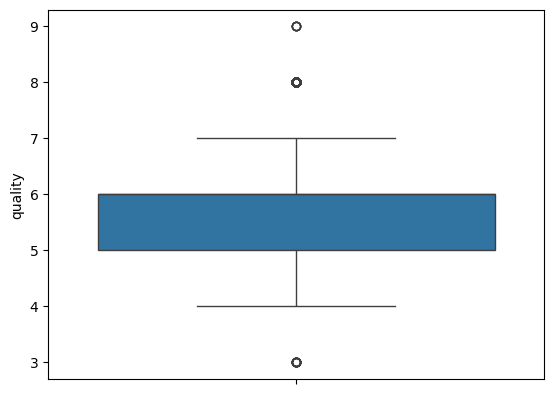

In [4]:
for col in data[:-1]:
    print("=" * 30, col, "=" * 30)
    sns.histplot(data[col])
    plt.show()
    sns.boxplot(data[col])
    plt.show()

In [5]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [6]:
data.drop('quality', axis=1).corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433


<Axes: >

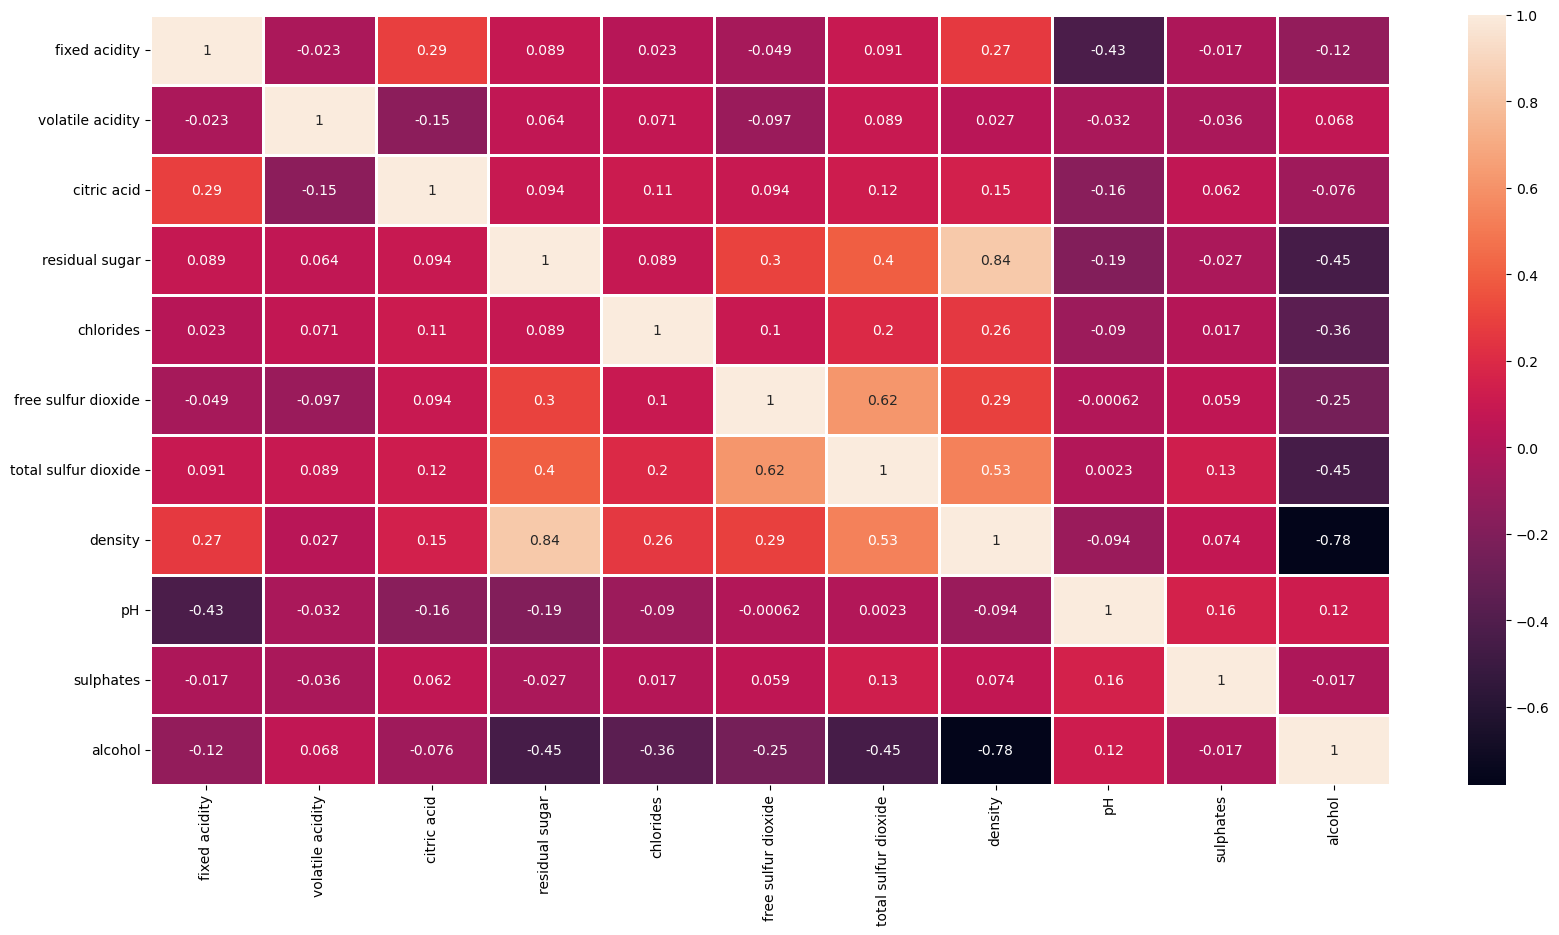

In [7]:
plt.figure(figsize=(20, 10))
sns.heatmap(data.drop('quality', axis=1).corr(), annot=True, linewidth=1)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [9]:
X = data.drop('quality', axis=1)
y = data['quality']

In [10]:
y.value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [11]:
y = pd.get_dummies(y)
y

,3,4,5,6,7,8,9
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
4893,False,False,False,True,False,False,False
4894,False,False,True,False,False,False,False
4895,False,False,False,True,False,False,False
4896,False,False,False,False,True,False,False


# 데이터를 train, valid, test 로 나누어 분석하기

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [13]:
print(len(X_train), len(X_valid), len(X_test))

2938 980 980


# 이상치가 많은 데이터이므로 RobustScaler 처리

In [14]:
rs = RobustScaler()
rs.fit(X_train)
train_temp = rs.transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index= X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index= X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index= X_test.index)

# 모델의 최고성능에서 저장하고 중지하기

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

2025-12-04 08:48:05.904202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 08:48:05.946956: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-04 08:48:07.131019: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [16]:
y_train.shape

(2938, 7)

In [17]:
n_class = y_train.shape[1]
model = Sequential()
model.add(Input(shape=(rs_X_train.shape[1], )))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(n_class, activation='softmax'))
model.summary()

I0000 00:00:1764805695.571698    4706 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import os

In [19]:
os.makedirs("./model", exist_ok=True) # model 디렉토리 자동 생성

Epoch 1/1000


2025-12-04 08:48:33.699435: I external/local_xla/xla/service/service.cc:163] XLA service 0x7db4b401c330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 08:48:33.699477: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-12-04 08:48:33.721703: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-04 08:48:33.138483: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


73/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3044 - loss: 1.6518

I0000 00:00:1764805714.555497    4753 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3880 - loss: 1.4726 - val_accuracy: 0.4531 - val_loss: 1.3159
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4714 - loss: 1.2667 - val_accuracy: 0.4857 - val_loss: 1.2537
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 1.2134 - val_accuracy: 0.5153 - val_loss: 1.2155
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5323 - loss: 1.1692 - val_accuracy: 0.5316 - val_loss: 1.1794
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5524 - loss: 1.1286 - val_accuracy: 0.5459 - val_loss: 1.1526
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5585 - loss: 1.0907 - val_accuracy: 0.5480 - val_loss: 1.1179
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5640 - loss: 1.0599 - val_accuracy: 0.5592 - val_loss: 1.0994
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5657 - loss: 1.0370 - val_accuracy: 0.5541 - val_l

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6940 - loss: 0.7706 - val_accuracy: 0.5724 - val_loss: 1.0998
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6886 - loss: 0.7640 - val_accuracy: 0.5816 - val_loss: 1.1001
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6896 - loss: 0.7633 - val_accuracy: 0.5582 - val_loss: 1.1153
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6947 - loss: 0.7501 - val_accuracy: 0.5776 - val_loss: 1.0990
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6995 - loss: 0.7482 - val_accuracy: 0.5704 - val_loss: 1.1043
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6988 - loss: 0.7437 - val_accuracy: 0.5673 - val_loss: 1.1222
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7090 - loss: 0.7358 - val_accuracy: 0.5663 - val_loss: 1.1158
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - loss: 0.7346 - val_accuracy: 0.5673 -

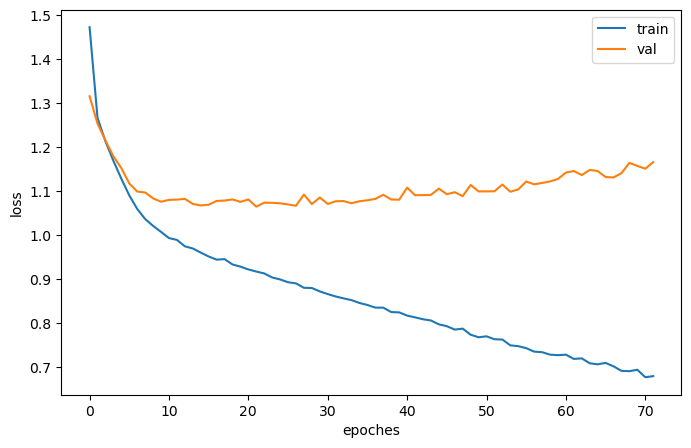

In [20]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=50)
filepath = "./model/witewine_best_model.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, y_train, epochs=1000, batch_size=32, validation_data=(rs_X_valid, y_valid), callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [21]:
pred = model.predict(rs_X_test)
pred = pd.DataFrame(pred)
pred

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,0,1,2,3,4,5,6
0,0.003376,0.013144,0.361658,0.449191,0.150832,0.021737,6.162799e-05
1,0.005493,0.002998,0.140861,0.613775,0.218905,0.017375,5.933232e-04
2,0.010903,0.100333,0.350204,0.514424,0.023721,0.000414,4.794996e-09
3,0.000116,0.001634,0.004602,0.530052,0.362615,0.100322,6.587856e-04
4,0.000994,0.004617,0.493584,0.490196,0.010390,0.000218,5.341628e-07
...,...,...,...,...,...,...,...
975,0.000029,0.001336,0.431433,0.465313,0.093434,0.008453,1.493956e-06
976,0.004299,0.003356,0.137138,0.806186,0.044330,0.004636,5.525401e-05
977,0.026807,0.065508,0.213171,0.686015,0.007471,0.001027,7.718571e-07
978,0.000028,0.000350,0.003411,0.095951,0.745703,0.154553,4.136953e-06


# 베스트모델 불러와서 예측

In [22]:
from keras.models import load_model

In [23]:
best_model = load_model("./model/witewine_best_model.keras")
pred2 = best_model.predict(rs_X_test)
pred2

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[5.72199281e-03, 2.44952757e-02, 4.28404272e-01, ...,
        1.49802208e-01, 1.62237007e-02, 2.60976097e-03],
       [4.05135285e-03, 9.85387154e-03, 3.61536354e-01, ...,
        1.14278808e-01, 1.12827457e-02, 9.26869165e-04],
       [1.69011131e-02, 2.12878332e-01, 4.28524673e-01, ...,
        8.46621022e-03, 2.33742828e-03, 4.45937330e-05],
       ...,
       [5.79052698e-03, 2.23455299e-02, 5.97405314e-01, ...,
        1.02162240e-02, 1.28319731e-03, 1.18855365e-04],
       [1.91825023e-03, 3.72861093e-03, 3.20212021e-02, ...,
        3.37150753e-01, 2.40371615e-01, 1.64003659e-03],
       [5.78276254e-03, 1.73796341e-02, 3.24871898e-01, ...,
        1.35516338e-02, 2.35034875e-03, 1.53697285e-04]],
      shape=(980, 7), dtype=float32)

In [24]:
best_model.evaluate(rs_X_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5480 - loss: 1.0387


[1.0387027263641357, 0.5479592084884644]

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
data = pd.read_csv("./data/winequality-white.csv", sep=";")
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [28]:
# for col in data[:-1]:
#     print("=" * 30, col, "=" * 30)
#     sns.histplot(data[col])
#     plt.show()
#     sns.boxplot(data[col])
#     plt.show()

In [29]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [30]:
data.drop('quality', axis=1).corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433


<Axes: >

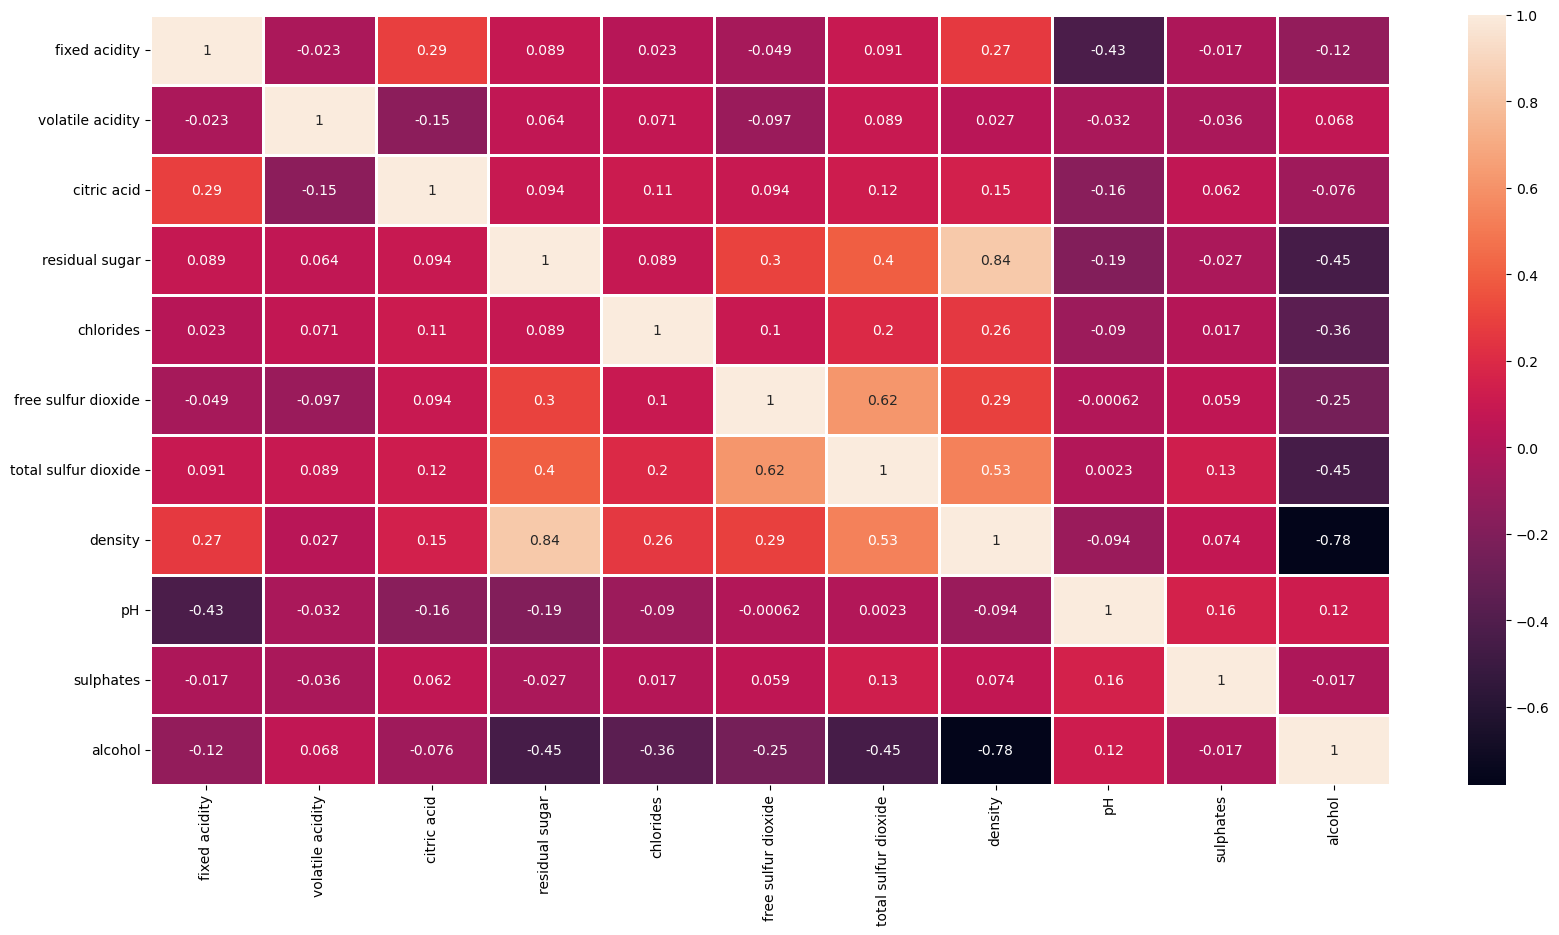

In [31]:
plt.figure(figsize=(20, 10))
sns.heatmap(data.drop('quality', axis=1).corr(), annot=True, linewidth=1)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [33]:
X = data.drop('quality', axis=1)
y = data['quality']

In [34]:
y.value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

# 데이터를 train, valid, test 로 나누어 분석하기

In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [36]:
print(len(X_train), len(X_valid), len(X_test))

2938 980 980


# 이상치가 많은 데이터이므로 RobustScaler 처리

In [37]:
rs = RobustScaler()
rs.fit(X_train)
train_temp = rs.transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index= X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index= X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index= X_test.index)

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)
y_test = le.transform(y_test)

# 모델의 최고성능에서 저장하고 중지하기

In [39]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [40]:
y_train.shape

(2938,)

In [41]:
n_class = 7
model2 = Sequential()
model2.add(Input(shape=(rs_X_train.shape[1], )))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(n_class, activation='softmax'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
import os

In [43]:
os.makedirs("./model", exist_ok=True) # model 디렉토리 자동 생성

In [44]:
y_train.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [45]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6])

# 불균형 데이터의 클래스에 가중치 주기

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights))
class_weights

{np.int64(0): np.float64(34.976190476190474),
 np.int64(1): np.float64(4.282798833819242),
 np.int64(2): np.float64(0.4802222948676038),
 np.int64(3): np.float64(0.31844786473011055),
 np.int64(4): np.float64(0.7949134199134199),
 np.int64(5): np.float64(3.9972789115646257),
 np.int64(6): np.float64(139.9047619047619)}

Epoch 1/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2835 - loss: 1.9361 - val_accuracy: 0.3000 - val_loss: 1.8458
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3033 - loss: 1.8245 - val_accuracy: 0.2908 - val_loss: 1.8128
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2737 - loss: 1.7134 - val_accuracy: 0.2194 - val_loss: 1.8076
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2509 - loss: 1.6107 - val_accuracy: 0.2612 - val_loss: 1.7074
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2485 - loss: 1.5247 - val_accuracy: 0.2592 - val_loss: 1.6909
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2859 - loss: 1.4039 - val_accuracy: 0.2388 - val_loss: 1.6777
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2886 - loss: 1.3148 - val_accuracy: 0.2918 - val_loss: 1.6219
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3162 - loss: 1.2384 - val_accuracy: 0

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5044 - loss: 0.6221 - val_accuracy: 0.4296 - val_loss: 1.2745
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5095 - loss: 0.6130 - val_accuracy: 0.4235 - val_loss: 1.2839
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5034 - loss: 0.6111 - val_accuracy: 0.4194 - val_loss: 1.2728
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5201 - loss: 0.5956 - val_accuracy: 0.4357 - val_loss: 1.2510
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5150 - loss: 0.5969 - val_accuracy: 0.4020 - val_loss: 1.3238
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5102 - loss: 0.5905 - val_accuracy: 0.4276 - val_loss: 1.2760
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5214 - loss: 0.5826 - val_accuracy: 0.4429 - val_loss: 1.2777
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5344 - loss: 0.5752 - val_accuracy: 0.4194 -

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6025 - loss: 0.4492 - val_accuracy: 0.4980 - val_loss: 1.3506
Epoch 102/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6079 - loss: 0.4242 - val_accuracy: 0.5020 - val_loss: 1.3351
Epoch 103/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6045 - loss: 0.4222 - val_accuracy: 0.4806 - val_loss: 1.3609
Epoch 104/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6079 - loss: 0.4246 - val_accuracy: 0.4867 - val_loss: 1.3536
Epoch 105/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6147 - loss: 0.4221 - val_accuracy: 0.5133 - val_loss: 1.3495
Epoch 106/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6232 - loss: 0.4112 - val_accuracy: 0.4857 - val_loss: 1.3646
Epoch 107/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6167 - loss: 0.4139 - val_accuracy: 0.4939 - val_loss: 1.3575
Epoch 108/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6150 - loss: 0.4102 - val_accuracy: 0

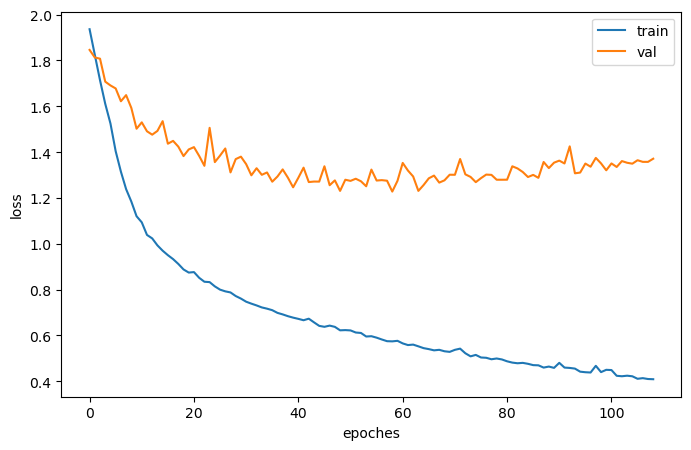

In [47]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=50)
filepath = "./model/witewine_best_model2.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model2.fit(rs_X_train, y_train, epochs=1000, batch_size=32, class_weight=class_weights,
                    validation_data=(rs_X_valid, y_valid), callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 베스트모델 불러와서 예측

In [48]:
from keras.models import load_model

In [49]:
best_model2 = load_model("./model/witewine_best_model2.keras")
pred2 = best_model2.predict(rs_X_test)
pred2

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[1.59308620e-08, 4.37776605e-03, 8.33174407e-01, ...,
        1.57173611e-02, 2.82186284e-06, 1.71205769e-13],
       [1.16174720e-04, 4.03794616e-01, 3.39344889e-01, ...,
        5.29686585e-02, 2.04603486e-02, 5.10481897e-08],
       [5.50412516e-08, 3.82342539e-03, 6.73631132e-01, ...,
        7.40276203e-02, 7.85700031e-05, 1.06205929e-11],
       ...,
       [3.91522844e-05, 2.56540428e-04, 7.41487369e-04, ...,
        1.49845127e-02, 2.36566253e-02, 9.51321244e-01],
       [3.82720964e-06, 3.24643433e-01, 1.88076004e-01, ...,
        1.12649985e-01, 1.04170546e-01, 7.32317247e-08],
       [1.60124141e-03, 3.15944853e-05, 3.44276011e-01, ...,
        9.42472443e-02, 2.99439689e-05, 1.34392971e-13]],
      shape=(980, 7), dtype=float32)

In [50]:
best_model2.evaluate(rs_X_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4827 - loss: 1.2640


[1.2639535665512085, 0.48265305161476135]